**Project Scope**
**Goal:**
Analyze biodiversity data to understand species distribution, conservation status, and observations across national parks.

**Load the Data**

In [1]:
import pandas as pd

species = pd.read_csv("/content/species_info.csv")
observations = pd.read_csv("/content/observations.csv")

species.head()
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


**Explore the Data**

In [2]:
#Check structure
species.info()
observations.info()
#Check missing values
species.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB


,0
category,0
scientific_name,0
common_names,0
conservation_status,5633


**Data Cleaning**

In [5]:
#Fill missing conservation status:
species['conservation_status'] = species['conservation_status'].fillna("Not Listed")

**Explore Species Data**

In [8]:
#Count species by category
species['category'].value_counts()
#Conservation status distribution
species['conservation_status'].value_counts()
#Species at risk
at_risk = species[species['conservation_status'] != "Not Listed"]
at_risk['category'].value_counts()


,count
category,
Bird,79
Vascular Plant,46
Mammal,38
Fish,11
Amphibian,7
Reptile,5
Nonvascular Plant,5


**Visualisations**

In [9]:
#Import libraries:

import seaborn as sns
import matplotlib.pyplot as plt

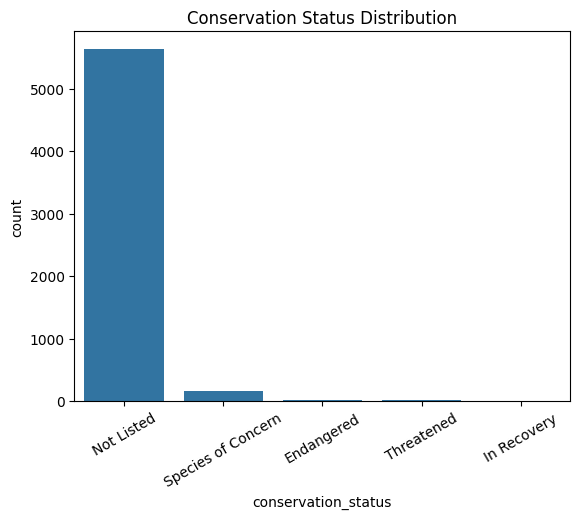

In [10]:
#A. Conservation Status Plot
sns.countplot(data=species, x='conservation_status')
plt.title("Conservation Status Distribution")
plt.xticks(rotation=30)
plt.show()

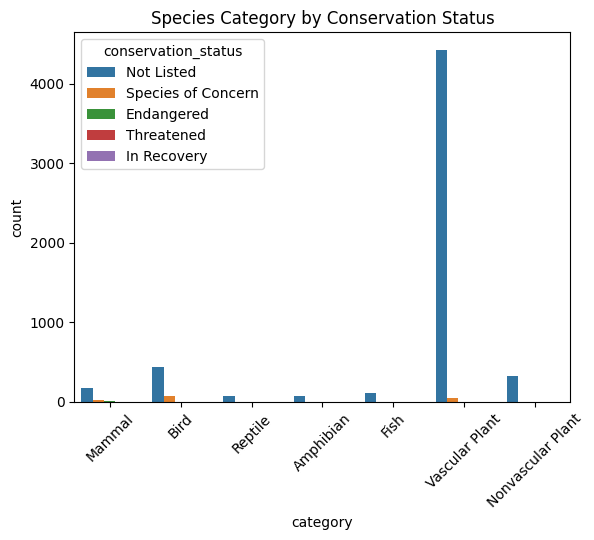

In [11]:
#B. Species Category vs Conservation
sns.countplot(data=species, x='category', hue='conservation_status')
plt.xticks(rotation=45)
plt.title("Species Category by Conservation Status")
plt.show()

**Merge Data**



In [12]:
merged = observations.merge(species, on='scientific_name')
merged.head()

,scientific_name,park_name,observations,category,common_names,conservation_status
0,Vicia benghalensis,Great Smoky Mountains National Park,68,Vascular Plant,"Purple Vetch, Reddish Tufted Vetch",Not Listed
1,Neovison vison,Great Smoky Mountains National Park,77,Mammal,American Mink,Not Listed
2,Prunus subcordata,Yosemite National Park,138,Vascular Plant,Klamath Plum,Not Listed
3,Abutilon theophrasti,Bryce National Park,84,Vascular Plant,Velvetleaf,Not Listed
4,Githopsis specularioides,Great Smoky Mountains National Park,85,Vascular Plant,Common Bluecup,Not Listed


**Observations Analysis**

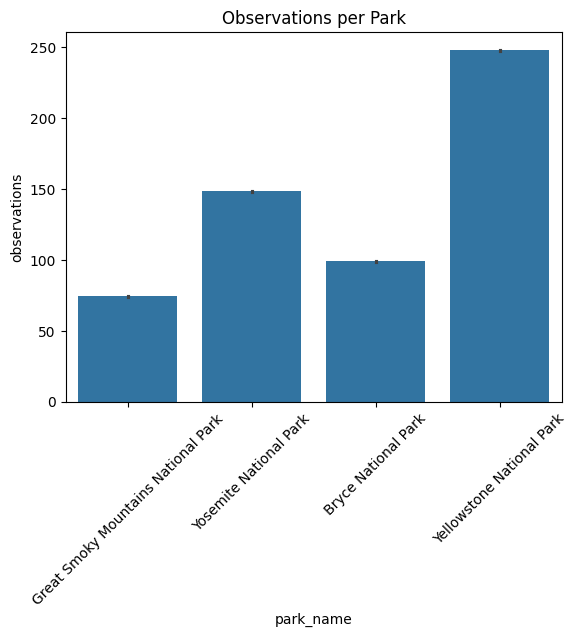

In [13]:
#Observations per park
merged.groupby('park_name')['observations'].sum()
#Species sightings per park
sns.barplot(data=merged, x='park_name', y='observations')
plt.xticks(rotation=45)
plt.title("Observations per Park")
plt.show()

<Axes: xlabel='park_name'>

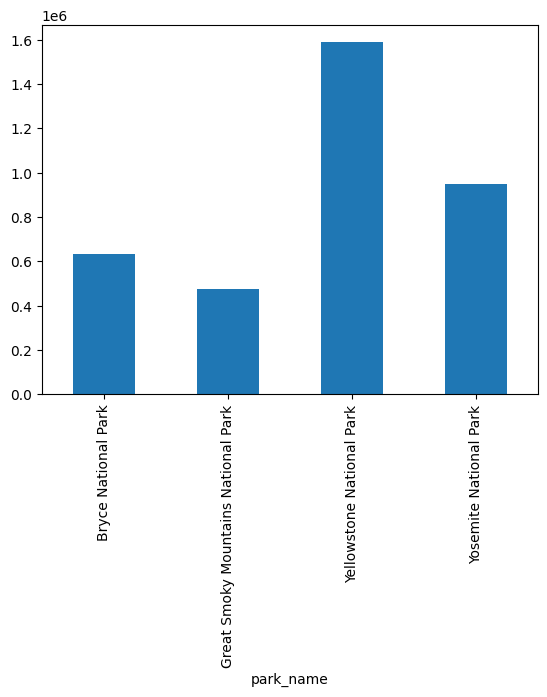

In [14]:
#If date exists → trends
merged.groupby('park_name')['observations'].sum().plot(kind='bar')